# Assignment 5

Assume you work for a record company. Your boss is interested in predicting ablum sales based on advertising. You are provided with the data in a file (*album_sales.csv*). 

There are 200 rows, where each row represents an album. There are also four columns. The first (*sales*) represents the sales of each album (in thousands) the week after release. The second (adverts) represents the amount (in thousands $) spent promoting the album prior to its release. The third (*airplay*) represents how many times it played on the radio. The fourth column (*attract*) represents the attractiveness of the band. 

## Instructions

### 1. Visualization (15 points)

Visualizing data is important to get a 'feel' of what the relationship between variables could be. For this part, **display the scatterplots between the following variables**.

- *sales* and *adverts*
- *sales* and *airplay*
- *sales* and *attract*

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

df = pd.read_csv("album_sales.csv")
df.head()

,sales,adverts,airplay,attract
0,330,10.256,43,10
1,120,985.685,28,7
2,360,1445.563,35,7
3,270,1188.193,33,7
4,220,574.513,44,5


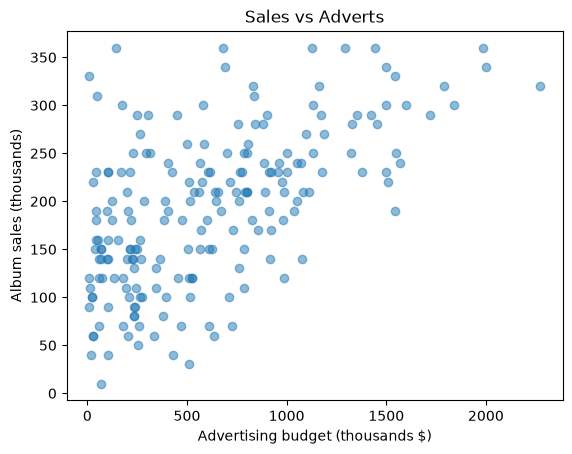

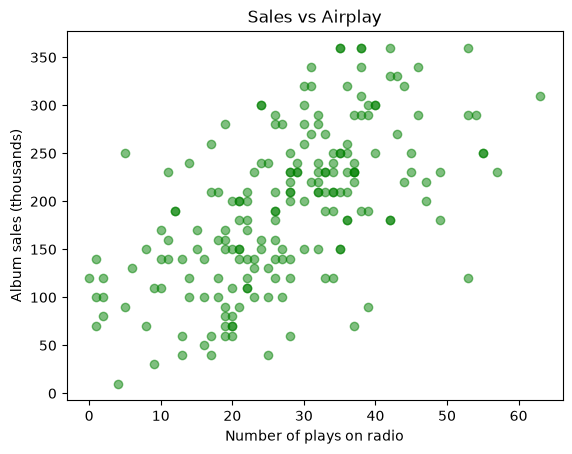

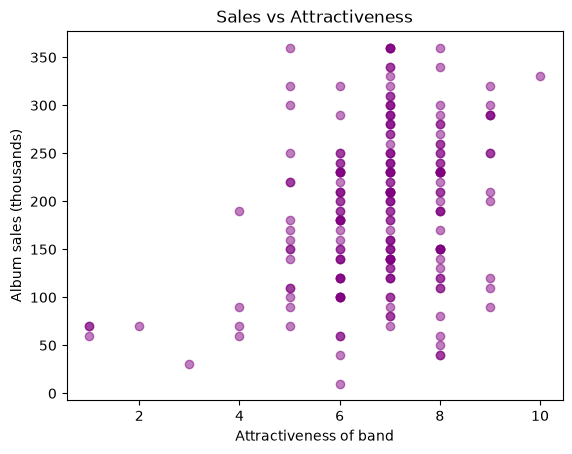

In [2]:
plt.scatter(df['adverts'], df['sales'], alpha=0.5)
plt.xlabel('Advertising budget (thousands $)')
plt.ylabel('Album sales (thousands)')
plt.title('Sales vs Adverts')
plt.show()

plt.scatter(df['airplay'], df['sales'], alpha=0.5, color='green')
plt.xlabel('Number of plays on radio')
plt.ylabel('Album sales (thousands)')
plt.title('Sales vs Airplay')
plt.show()

plt.scatter(df['attract'], df['sales'], alpha=0.5, color='purple')
plt.xlabel('Attractiveness of band')
plt.ylabel('Album sales (thousands)')
plt.title('Sales vs Attractiveness')
plt.show()

In the empty `Markdown` cell below, describe the relationship (or lack thereof) portrayed by the scatterplots you generated. 

**Sales and adverts:** There is a clear positive relationship. Albums with bigger advertising budgets tend to sell more, and the points drift upward from left to right. The spread is fairly wide, so advertising is not the only thing driving sales, but the trend is there.

**Sales and airplay:** This also shows a positive relationship, and the points look a bit more tightly clustered around the trend than the adverts plot. The more times an album is played on the radio, the higher its sales tend to be.

**Sales and attract:** The relationship here is weak. Attractiveness only takes whole-number values from about 1 to 10, so the plot is a set of vertical strips. Most bands are rated 6-8, and within those strips sales are spread all over the place. There is a slight upward drift (the lowest ratings have the lowest sales), but it is much weaker than the other two.

### 2. Linear Regression (35 points)

- Conduct a linear regression to construct a linear model between *sales* and *adverts*
- Display the **F-statistic** and **P-value**
    - Use the `statsmodels.api` module for this -- may need to install via `pip`
    - Note that **X**, your predictor(s), will consist of *adverts* and that **y**, your constant, will consist of *sales*
    - The values you need can be accessed via the `summary()` function of your model object

In [3]:
x = df['adverts']
y = df['sales']
x = sm.add_constant(x)

model = sm.OLS(y, x).fit()
predictions = model.predict(x)
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.331
Method:                 Least Squares   F-statistic:                     99.59
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           2.94e-19
Time:                        13:38:33   Log-Likelihood:                -1120.7
No. Observations:                 200   AIC:                             2245.
Df Residuals:                     198   BIC:                             2252.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        134.1399      7.537     17.799      0.0

In [4]:
print("F-statistic:", model.fvalue)
print("P-value (Prob F-statistic):", model.f_pvalue)

F-statistic: 99.5868714961987
P-value (Prob F-statistic): 2.941979852165935e-19


In the empty `Markdown` cell below, describe whether the **F-statistic** and **P-value** describe about our linear regression model. (I.e., Is it good? Bad? No bearing?)

The **F-statistic is about 99.59** with a **P-value of about 2.94e-19** (essentially zero, far below 0.05).

The F-test asks whether the model does a better job of predicting sales than just guessing the average sales every time. A large F with a P-value under 0.05 means the answer is yes, so the model is statistically significant and advertising really does help predict sales.

That said, the R-squared is only 0.335, which means advertising alone explains about 33.5% of the variation in album sales. So it is a **good, significant model, but not a complete one** -- about two thirds of what drives sales is still unexplained.

### 3. Model Coefficients (10 points)

- Make note of the **intercept** value and **coefficient** (adverts) value of your linear regression model. 

The regression line is described using this equation: *Y = b<sub>0</sub> + b<sub>1</sub>X<sub>1</sub>* where each variable represents the following:

- Y denotes the sales
- *b<sub>0</sub>* denotes the **intercept** value
- *b<sub>1</sub>* denotes the advertising budget **coefficient**
- *X<sub>2</sub>* denotes the advertising budget

The equation then becomes *Album Sales = intercept value + (coefficient * advertising budget)*. 

Using the intercept value and coefficient of your linear model, **calculate and display how many records will be sold if $135,000 was spent on advertising an album**.

In [5]:
intercept = model.params['const']
coefficient = model.params['adverts']

print("Intercept (b0):", intercept)
print("Coefficient (b1):", coefficient)

advertising_budget = 135
predicted_sales = intercept + (coefficient * advertising_budget)

print()
print(f"Album Sales = {intercept:.3f} + ({coefficient:.5f} * {advertising_budget})")
print(f"Predicted sales: {predicted_sales:.3f} thousand records")
print(f"That is about {predicted_sales * 1000:,.0f} records sold.")

Intercept (b0): 134.13993781207427
Coefficient (b1): 0.09612448597387713

Album Sales = 134.140 + (0.09612 * 135)
Predicted sales: 147.117 thousand records
That is about 147,117 records sold.


### 4. Multiple Regression (40 points)
- Conduct a **multiple regression** to construct a model between *sales* and the predictors (*adverts*, *airplay*, and *attract*)
    - Note that **X**, your predictors will consist of *adverts*, *airplay*, and *attractiveness*, and **y**, your constant, will consist of *sales*
- Display the summary of the multiple regression model using the `summary()` function to obtain the relevant values

In [6]:
x = df[['adverts', 'airplay', 'attract']]
y = df['sales']
x = sm.add_constant(x)

multi_model = sm.OLS(y, x).fit()
multi_predictions = multi_model.predict(x)
print(multi_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.660
Method:                 Least Squares   F-statistic:                     129.5
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           2.88e-46
Time:                        13:38:33   Log-Likelihood:                -1052.2
No. Observations:                 200   AIC:                             2112.
Df Residuals:                     196   BIC:                             2126.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -26.6130     17.350     -1.534      0.1

We know that the R<sup>2</sup> (R-Squared) value can be used to evaluate the overall fit of a linear model. We also know that R<sup>2</sup> is between 0 and 1 -- higher values are better because it means that more variance is explained by the model. **Higher R<sup>2</sup> values are better if their P-values are < 0.05**.

Bsed on this, discuss **which one of the two models you constructed is better** in the empty `Markdown` cell below. 
* Model 1: The linear model between *sales* and *adverts* you constructed
* Model 2: The multiple regression model between (*sales*) and the predictors (*adverts*, *airplay*, and *attract*) you constructed

**Model 2 (the multiple regression) is the better model.**

| | Model 1 (adverts only) | Model 2 (adverts + airplay + attract) |
|---|---|---|
| R-squared | 0.335 | 0.665 |
| Adjusted R-squared | 0.331 | 0.660 |
| F-statistic | 99.59 | 129.50 |
| Prob (F-statistic) | 2.94e-19 | 2.88e-46 |

Model 1 explains about 33.5% of the variation in album sales. Model 2 explains about 66.5% -- roughly double. Both models are significant (P-values far below 0.05), so the higher R-squared is trustworthy and not just noise.

It also is not the case that R-squared went up only because we added more predictors: the **adjusted** R-squared, which penalizes extra predictors, also nearly doubled (0.331 to 0.660). On top of that, all three predictors are individually significant (adverts P = 5.05e-26, airplay P = 1.33e-25, attract P = 9.49e-06), so each one is pulling its weight.

In plain terms: how much you spend on advertising matters, but radio play and the band's attractiveness matter too, and using all three gives a much better picture of how an album will sell.

### Submission
- Submit this `Jupyter` file to D2L, renamed as **Last_First_Assignment4.ipynb** 
    - Replace '**Last**' and '**First**' with your first and last name